## Gradient Boosting Classifier
- xgboost
- lightgbm

In [1]:
# Imports
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
import cupy as cp
import numpy as np
from sklearn.metrics import classification_report

In [2]:
# Parameters
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Data Preprocessing

In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df = pd.read_csv('../datasets/challenger_dataset.csv')

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

#trying to modify the dataset
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf['winner'] = df['winner']

In [4]:
# Splitting the data
from sklearn.model_selection import train_test_split

X_gpu = cp.asarray(tdf.drop('winner', axis=1))
y_gpu = cp.asarray(tdf['winner'])

X_cpu = tdf.drop('winner', axis=1)
y_cpu = tdf['winner']

X_train_gpu, X_test_gpu, y_train_gpu, y_test_gpu = train_test_split(X_gpu , y_gpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)
X_train_cpu, X_test_cpu, y_train_cpu, y_test_cpu = train_test_split(X_cpu, y_cpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)


assert X_train_cpu.shape[0] == y_train_cpu.shape[0]
assert X_test_cpu.shape[0] == y_test_cpu.shape[0]

X_train_cpu.shape, X_test_cpu.shape, y_train_cpu.shape, y_test_cpu.shape

((351852, 5), (87964, 5), (351852,), (87964,))

## Training XGBoost

In [5]:
xgb_model = XGBClassifier(eval_metric='auc', random_state=RANDOM_STATE, device="cuda")
xgb_model.fit(X_train_gpu, y_train_gpu)
pred = xgb_model.predict(X_test_gpu)
print(classification_report(y_test_cpu, pred))

              precision    recall  f1-score   support

           0       0.73      0.77      0.75     45016
           1       0.74      0.70      0.72     42948

    accuracy                           0.74     87964
   macro avg       0.74      0.74      0.74     87964
weighted avg       0.74      0.74      0.74     87964



## Training LightGBM

In [6]:
lgb_model = lgb.LGBMClassifier(random_state=RANDOM_STATE, force_col_wise=True)
lgb_model.fit(X_train_cpu, y_train_cpu)
pred = lgb_model.predict(X_test_cpu)
print(classification_report(y_test_cpu, pred))

[LightGBM] [Info] Number of positive: 172108, number of negative: 179744
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 351852, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489149 -> initscore=-0.043411
[LightGBM] [Info] Start training from score -0.043411
              precision    recall  f1-score   support

           0       0.73      0.78      0.75     45016
           1       0.75      0.70      0.72     42948

    accuracy                           0.74     87964
   macro avg       0.74      0.74      0.74     87964
weighted avg       0.74      0.74      0.74     87964



## Grid Search

In [7]:
import xgboost as xgb
import numpy as np
import itertools
from tqdm import tqdm
import time


def grid_search(param_grid, build_model,  X_train, y_train, X_test, y_test):
    best_score = -np.inf
    best_params = {}

    param_combinations = itertools.product(*param_grid.values())
    len_data =np.prod([len(v) for v in param_grid.values()])
    print(f"Starting grid search over {len_data} parameter combinations...\n")


    start_time = time.time()

    for i, combination in enumerate(tqdm(param_combinations, desc="Grid Search Progress", total=len_data)):
        params = dict(zip(param_grid.keys(), combination))

        model = build_model(params)

        model.fit(X_train, y_train)

        y_pred = model.predict_proba(X_test)[:, 1]
        avg_auc = roc_auc_score(y_test, y_pred)

        if avg_auc > best_score:
            best_score = avg_auc
            best_params = params

    end_time = time.time()
    time_taken = end_time - start_time
    print(f"\nGrid Search Completed in {time_taken:.2f} seconds.")

    print(f"\nBest Parameters: {best_params}")
    print(f"Best AUC Score: {best_score:.4f}")
    return best_params

## Hyperparameter Tuning with GridSearchCV for XGBoost

In [8]:
params_XG = {
    'n_estimators': [250, 300, 350],
    'max_depth': [6, 7, 8],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.85, 0.9, 0.95],
    'colsample_bytree': [0.9, 1.0],
    'gamma': [0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [0.3, 0.5, 0.7],
    'min_child_weight': [1, 2, 3],
}


best_params = grid_search(params_XG,
                lambda params: xgb.XGBClassifier(**params, n_jobs=-1, random_state=RANDOM_STATE, device="cuda"),
                X_train_gpu, y_train_gpu, X_test_gpu, y_test_cpu)

xgb_model = XGBClassifier(**best_params, eval_metric='auc', random_state=RANDOM_STATE, device="cuda")
xgb_model.fit(X_train_gpu, y_train_gpu)
pred = xgb_model.predict(X_test_gpu)
print(classification_report(y_test_cpu, pred))

Starting grid search over 13122 parameter combinations...



Grid Search Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 13122/13122 [2:53:43<00:00,  1.26it/s]



Grid Search Completed in 10423.27 seconds.

Best Parameters: {'n_estimators': 350, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.95, 'colsample_bytree': 1.0, 'gamma': 0.4, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'min_child_weight': 1}
Best AUC Score: 0.8306
              precision    recall  f1-score   support

           0       0.73      0.77      0.75     45016
           1       0.74      0.71      0.72     42948

    accuracy                           0.74     87964
   macro avg       0.74      0.74      0.74     87964
weighted avg       0.74      0.74      0.74     87964



## Hyperparameter Tuning with GridSearchCV for LightGBM

In [9]:
params_LGB = {
    'n_estimators': [100, 200, 300],
    'max_depth': [7, 9, 11],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [0.5, 1, 2],
    'min_child_weight': [1, 2, 5],
}

best_params = grid_search(params_LGB,
                lambda params: lgb.LGBMClassifier(**params, random_state=RANDOM_STATE, force_col_wise=True, verbose=0),
                X_train_cpu, y_train_cpu, X_test_cpu, y_test_cpu)

lgb_model = lgb.LGBMClassifier(**best_params, random_state=RANDOM_STATE, force_col_wise=True)
lgb_model.fit(X_train_cpu, y_train_cpu)
pred = lgb_model.predict(X_test_cpu)
print(classification_report(y_test_cpu, pred))

Starting grid search over 4374 parameter combinations...



Grid Search Progress:   4%|████▏                                                                                                           | 165/4374 [01:42<39:53,  1.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Grid Search Progress:   4%|████▎                                                                                                           | 168/4374 [01:44<38:17,  1.83it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Grid Search Progress:  78%|██████████████████████████████████████████████████████████████████████████████████████▎                        | 3401/4374 [46:12<19:37,  1.21s/it]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Grid Search Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4374/4374 [1:06:32<00:00,  1.10it/s]



Grid Search Completed in 3992.81 seconds.

Best Parameters: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.05, 'reg_lambda': 0.5, 'min_child_weight': 1}
Best AUC Score: 0.8305
              precision    recall  f1-score   support

           0       0.73      0.77      0.75     45016
           1       0.75      0.70      0.72     42948

    accuracy                           0.74     87964
   macro avg       0.74      0.74      0.74     87964
weighted avg       0.74      0.74      0.74     87964



## Model Evaluation

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    return accuracy, precision, recall, f1, auc

xgb_results = evaluate_model(xgb_model, X_test_gpu, y_test_cpu)
lgb_results = evaluate_model(lgb_model, X_test_cpu, y_test_cpu)

print(f'XGBoost - Accuracy: {xgb_results[0]}, Precision: {xgb_results[1]}, Recall: {xgb_results[2]}, F1-Score: {xgb_results[3]}, AUC-ROC: {xgb_results[4]}')
print(f'LightGBM - Accuracy: {lgb_results[0]}, Precision: {lgb_results[1]}, Recall: {lgb_results[2]}, F1-Score: {lgb_results[3]}, AUC-ROC: {lgb_results[4]}')

XGBoost - Accuracy: 0.7382792960756673, Precision: 0.7447310243183493, Recall: 0.7059234423023191, F1-Score: 0.7248081474575055, AUC-ROC: 0.7375360947072285
LightGBM - Accuracy: 0.7385748715383565, Precision: 0.7476786334971945, Recall: 0.7011967961255472, F1-Score: 0.7236921154446928, AUC-ROC: 0.7377163116934827


## Confusion Matrix & ROC Curve

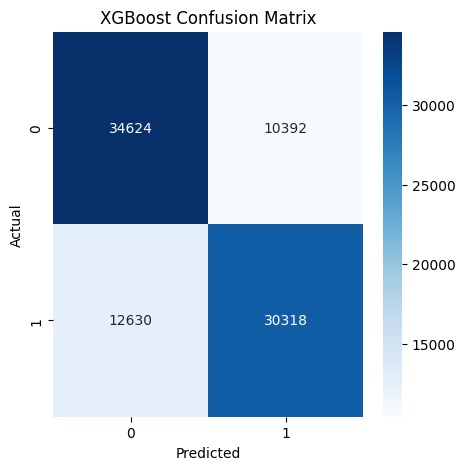

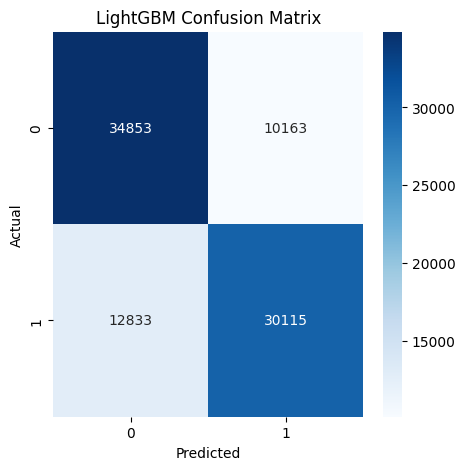

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(model, X_test, y_test, title):
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(xgb_model, X_test_gpu, y_test_cpu, 'XGBoost Confusion Matrix')
plot_confusion_matrix(lgb_model, X_test_cpu, y_test_cpu, 'LightGBM Confusion Matrix')

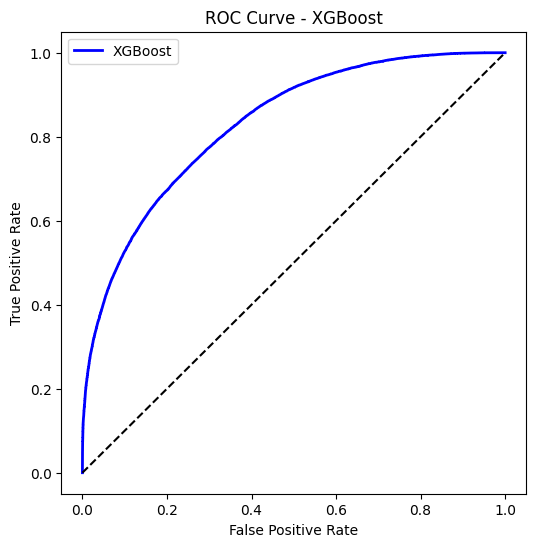

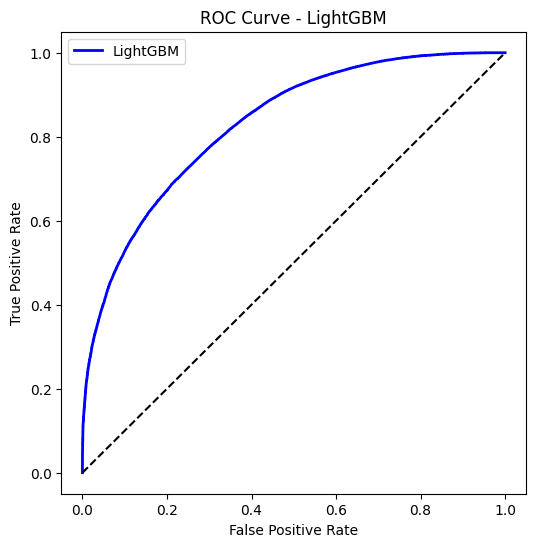

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_test, y_test, label):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    plt.figure(figsize=(6, 6))  # Create a new figure for each plot
    plt.plot(fpr, tpr, label=label, linewidth=2, color='blue')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend()
    plt.show()

# Plot each model separately
plot_roc_curve(xgb_model, X_test_gpu, y_test_cpu, 'XGBoost')
plot_roc_curve(lgb_model, X_test_cpu, y_test_cpu, 'LightGBM')